In [4]:
import pandas as pd

df = pd.read_csv(r"C:\Users\PC\OneDrive\Desktop\CE477\Extended_Employee_Performance_and_Productivity_Data.csv")
df.head()


,Employee_ID,Department,Gender,Age,Job_Title,Hire_Date,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score,Resigned
0,1,IT,Male,55,Specialist,2022-01-19 08:03:05.556036,2,High School,5,6750.0,33,32,22,2,0,14,66,0,2.63,False
1,2,Finance,Male,29,Developer,2024-04-18 08:03:05.556036,0,High School,5,7500.0,34,34,13,14,100,12,61,2,1.72,False
2,3,Finance,Male,55,Specialist,2015-10-26 08:03:05.556036,8,High School,3,5850.0,37,27,6,3,50,10,1,0,3.17,False
3,4,Customer Support,Female,48,Analyst,2016-10-22 08:03:05.556036,7,Bachelor,2,4800.0,52,10,28,12,100,10,0,1,1.86,False
4,5,Engineering,Female,36,Analyst,2021-07-23 08:03:05.556036,3,Bachelor,2,4800.0,38,11,29,13,100,15,9,1,1.25,False


In [5]:
df.shape, df.columns


((100000, 20),
 Index(['Employee_ID', 'Department', 'Gender', 'Age', 'Job_Title', 'Hire_Date',
        'Years_At_Company', 'Education_Level', 'Performance_Score',
        'Monthly_Salary', 'Work_Hours_Per_Week', 'Projects_Handled',
        'Overtime_Hours', 'Sick_Days', 'Remote_Work_Frequency', 'Team_Size',
        'Training_Hours', 'Promotions', 'Employee_Satisfaction_Score',
        'Resigned'],
       dtype='object'))

In [6]:
df['Resigned'].value_counts()


Resigned
False    89990
True     10010
Name: count, dtype: int64

In [7]:
df.columns


Index(['Employee_ID', 'Department', 'Gender', 'Age', 'Job_Title', 'Hire_Date',
       'Years_At_Company', 'Education_Level', 'Performance_Score',
       'Monthly_Salary', 'Work_Hours_Per_Week', 'Projects_Handled',
       'Overtime_Hours', 'Sick_Days', 'Remote_Work_Frequency', 'Team_Size',
       'Training_Hours', 'Promotions', 'Employee_Satisfaction_Score',
       'Resigned'],
      dtype='object')

In [8]:
y = df['Resigned']

drop_cols = ['Resigned', 'EmployeeID', 'Name', 'Hire_Date']

X = df.drop(columns=[c for c in drop_cols if c in df.columns])

X.shape, y.shape

((100000, 18), (100000,))

In [9]:
!pip install scikit-learn



In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

len(X_train), len(X_test)

(80000, 20000)

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

cat_cols = X.select_dtypes(include=['object']).columns.tolist()

num_cols = X.select_dtypes(exclude=['object']).columns.tolist()

cat_cols, num_cols


(['Department', 'Gender', 'Job_Title', 'Education_Level'],
 ['Employee_ID',
  'Age',
  'Years_At_Company',
  'Performance_Score',
  'Monthly_Salary',
  'Work_Hours_Per_Week',
  'Projects_Handled',
  'Overtime_Hours',
  'Sick_Days',
  'Remote_Work_Frequency',
  'Team_Size',
  'Training_Hours',
  'Promotions',
  'Employee_Satisfaction_Score'])

In [12]:
from sklearn.pipeline import Pipeline

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols)
    ]
)


In [13]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

dt_model = Pipeline(steps=[
    ("prep", preprocess),
    ("model", DecisionTreeClassifier(max_depth=5, random_state=42))
])

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred_dt)
acc_dt


0.8997

In [14]:
print(classification_report(y_test, y_pred_dt))


              precision    recall  f1-score   support

       False       0.90      1.00      0.95     17998
        True       0.17      0.00      0.00      2002

    accuracy                           0.90     20000
   macro avg       0.53      0.50      0.47     20000
weighted avg       0.83      0.90      0.85     20000



In [15]:
!pip install imblearn


In [16]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_train_res, y_train_res = ros.fit_resample(X_train, y_train)

y_train_res.value_counts()


Resigned
False    71992
True     71992
Name: count, dtype: int64

In [17]:
dt_model.fit(X_train_res, y_train_res)
y_pred_dt2 = dt_model.predict(X_test)

print(classification_report(y_test, y_pred_dt2))


              precision    recall  f1-score   support

       False       0.90      0.64      0.75     17998
        True       0.10      0.36      0.15      2002

    accuracy                           0.61     20000
   macro avg       0.50      0.50      0.45     20000
weighted avg       0.82      0.61      0.69     20000



In [18]:
from sklearn.linear_model import LogisticRegression

log_model = Pipeline(steps=[
    ("prep", preprocess),
    ("model", LogisticRegression(max_iter=2000))
])

log_model.fit(X_train_res, y_train_res)
y_pred_log = log_model.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

acc_log = accuracy_score(y_test, y_pred_log)
print("Logistic Regression Accuracy:", acc_log)
print(classification_report(y_test, y_pred_log))


Logistic Regression Accuracy: 0.50535
              precision    recall  f1-score   support

       False       0.90      0.51      0.65     17998
        True       0.10      0.48      0.16      2002

    accuracy                           0.51     20000
   macro avg       0.50      0.49      0.41     20000
weighted avg       0.82      0.51      0.60     20000



c:\Users\PC\OneDrive\Desktop\CE477\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [19]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(steps=[
    ("prep", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

rf_model.fit(X_train_res, y_train_res)
y_pred_rf = rf_model.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

acc_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", acc_rf)
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.8999
              precision    recall  f1-score   support

       False       0.90      1.00      0.95     17998
        True       0.00      0.00      0.00      2002

    accuracy                           0.90     20000
   macro avg       0.45      0.50      0.47     20000
weighted avg       0.81      0.90      0.85     20000



c:\Users\PC\OneDrive\Desktop\CE477\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\PC\OneDrive\Desktop\CE477\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\PC\OneDrive\Desktop\CE477\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

In [20]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(steps=[
    ("prep", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

rf_model.fit(X_train_res, y_train_res)
y_pred_rf = rf_model.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

acc_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", acc_rf)
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.8999
              precision    recall  f1-score   support

       False       0.90      1.00      0.95     17998
        True       0.00      0.00      0.00      2002

    accuracy                           0.90     20000
   macro avg       0.45      0.50      0.47     20000
weighted avg       0.81      0.90      0.85     20000



c:\Users\PC\OneDrive\Desktop\CE477\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\PC\OneDrive\Desktop\CE477\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\PC\OneDrive\Desktop\CE477\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

In [21]:
acc_dt2 = accuracy_score(y_test, y_pred_dt2)

import pandas as pd

acc_table = pd.DataFrame({
    "Algorithm": ["Decision Tree", "Logistic Regression", "Random Forest"],
    "Accuracy": [acc_dt2, acc_log, acc_rf]
})

acc_table


,Algorithm,Accuracy
0,Decision Tree,0.60915
1,Logistic Regression,0.50535
2,Random Forest,0.89990


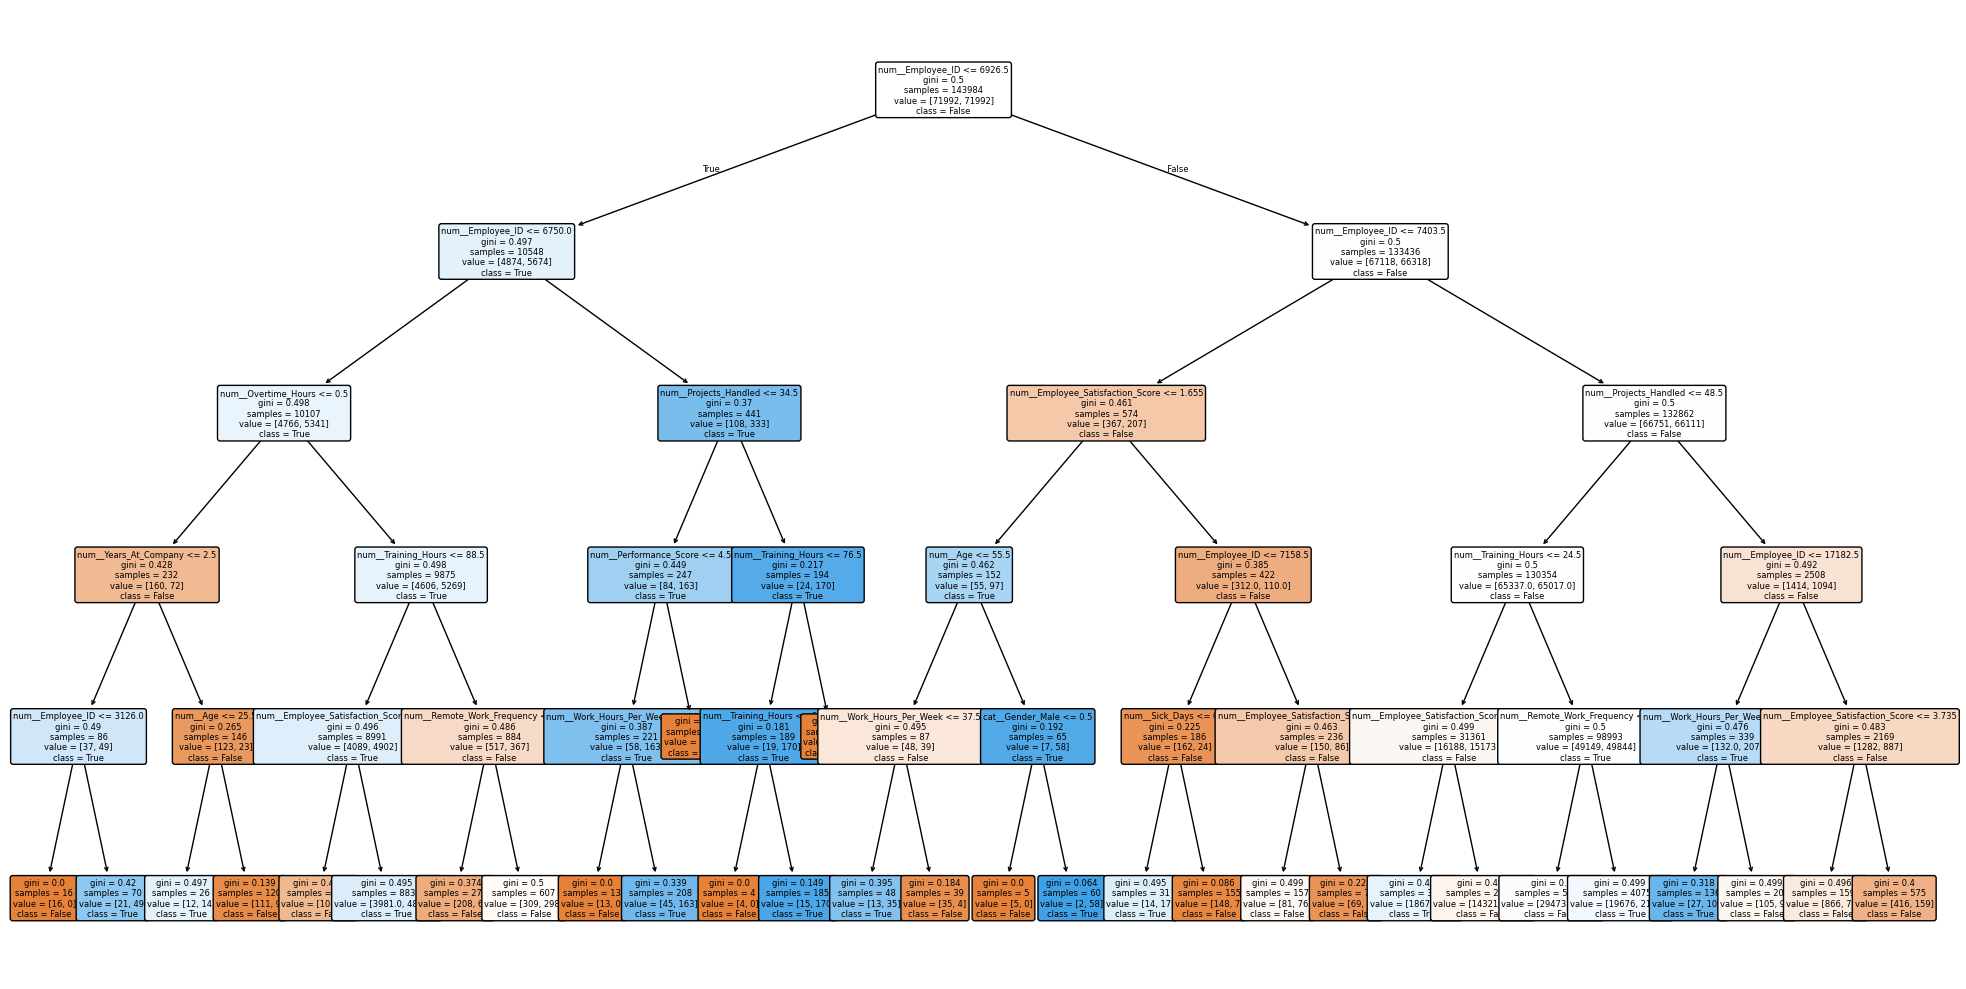

In [22]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree

X_train_res_trans = preprocess.fit_transform(X_train_res)
dt_vis = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_vis.fit(X_train_res_trans, y_train_res)

feature_names = preprocess.get_feature_names_out()

plt.figure(figsize=(20, 10))
plot_tree(
    dt_vis,
    feature_names=feature_names,
    class_names=["False", "True"],
    filled=True,
    rounded=True,
    fontsize=6
)
plt.tight_layout()
plt.show()


In [43]:
import numpy as np

dt_temp = DecisionTreeClassifier(max_depth=5, random_state=42)
pipe = Pipeline([("prep", preprocess), ("model", dt_temp)])
pipe.fit(X_train_res, y_train_res)

encoded_names = pipe.named_steps['prep'].get_feature_names_out()

importances = pipe.named_steps['model'].feature_importances_

top_idx = np.argsort(importances)[-20:]
top_features = encoded_names[top_idx]

top_features


array(['cat__Job_Title_Specialist', 'cat__Job_Title_Technician',
       'cat__Education_Level_Bachelor', 'cat__Education_Level_PhD',
       'cat__Education_Level_Master', 'num__Monthly_Salary',
       'num__Team_Size', 'num__Promotions', 'cat__Gender_Male',
       'num__Sick_Days', 'num__Years_At_Company', 'num__Overtime_Hours',
       'num__Age', 'num__Performance_Score', 'num__Projects_Handled',
       'num__Remote_Work_Frequency', 'num__Work_Hours_Per_Week',
       'num__Training_Hours', 'num__Employee_Satisfaction_Score',
       'num__Employee_ID'], dtype=object)

In [47]:

model = dt_model.named_steps["model"]
importances = model.feature_importances_
feature_names = preprocess.get_feature_names_out()

import pandas as pd
imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)
imp.head(15)



num__Employee_ID                    0.261727
num__Employee_Satisfaction_Score    0.203018
num__Training_Hours                 0.108104
num__Work_Hours_Per_Week            0.087048
num__Remote_Work_Frequency          0.086346
num__Projects_Handled               0.052872
num__Performance_Score              0.045455
num__Age                            0.042835
num__Overtime_Hours                 0.040571
num__Years_At_Company               0.033035
num__Sick_Days                      0.023498
cat__Gender_Male                    0.015491
cat__Department_Customer Support    0.000000
cat__Department_IT                  0.000000
cat__Department_HR                  0.000000
dtype: float64

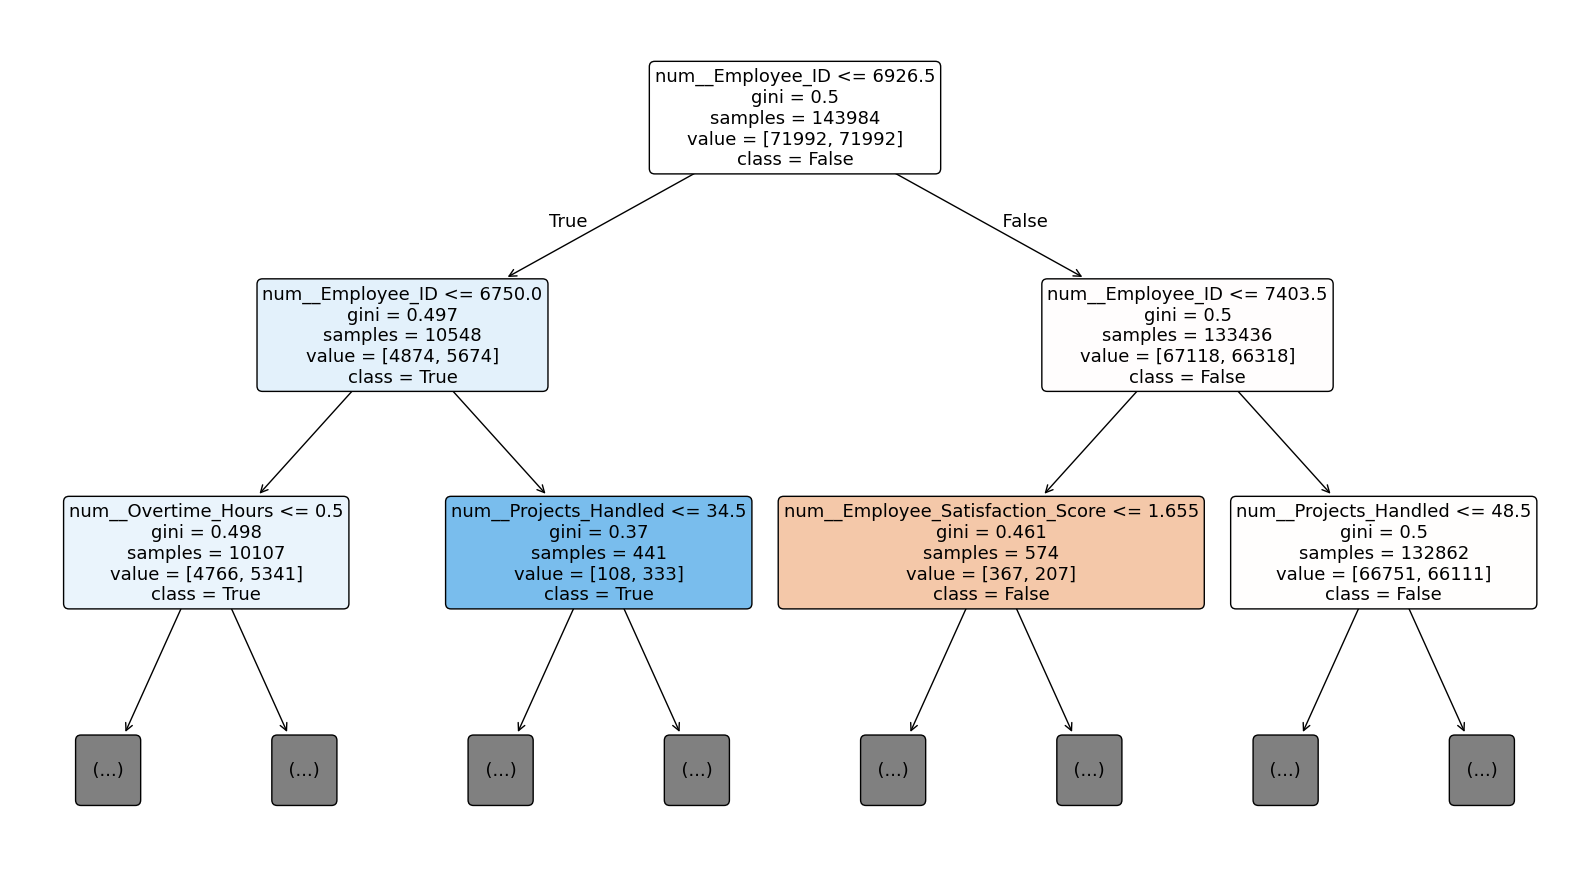

In [ ]:
plt.figure(figsize=(16, 9)) 
plot_tree(
    dt_vis,
    feature_names=feature_names,
    class_names=["False", "True"],
    filled=True,
    rounded=True,
    fontsize=13,
    max_depth=2   
)
plt.tight_layout()
plt.savefig("decision_tree.png", dpi=300, bbox_inches="tight")
plt.show()



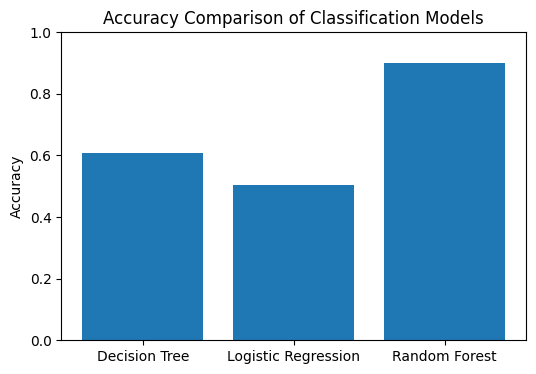

In [23]:
import matplotlib.pyplot as plt

models = ["Decision Tree", "Logistic Regression", "Random Forest"]
accuracies = [acc_dt2, acc_log, acc_rf]

plt.figure(figsize=(6,4))
plt.bar(models, accuracies)
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison of Classification Models")
plt.ylim(0, 1)
plt.show()


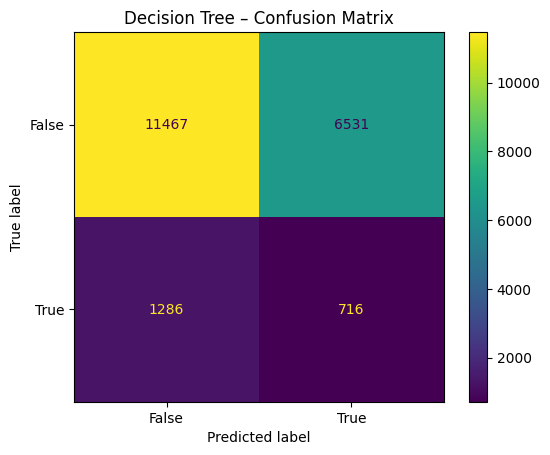

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt2)
plt.title("Decision Tree – Confusion Matrix")
plt.show()


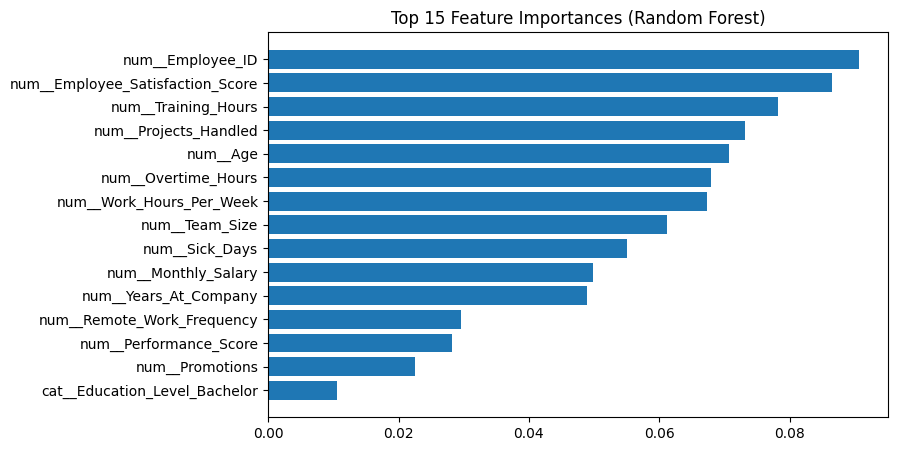

In [25]:
import numpy as np

rf = rf_model.named_steps["model"]

importances = rf.feature_importances_
feature_names = preprocess.get_feature_names_out()

indices = np.argsort(importances)[::-1][:15]

plt.figure(figsize=(8,5))
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), feature_names[indices])
plt.title("Top 15 Feature Importances (Random Forest)")
plt.gca().invert_yaxis()
plt.show()


In [26]:
#regression part below

In [27]:
target_reg = "Performance_Score"

y_reg = df[target_reg]

X_reg = df.drop(columns=["Performance_Score", "Resigned"]) 


In [28]:
from sklearn.model_selection import train_test_split

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

Xr_train.shape, Xr_test.shape


((80000, 18), (20000, 18))

In [29]:
cat_cols_reg = X_reg.select_dtypes(include=['object']).columns.tolist()
num_cols_reg = X_reg.select_dtypes(exclude=['object']).columns.tolist()

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocess_reg = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_reg),
    ("num", "passthrough", num_cols_reg)
])


In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

lin_reg_model = Pipeline(steps=[
    ("prep", preprocess_reg),
    ("model", LinearRegression())
])

lin_reg_model.fit(Xr_train, yr_train)
pred_lin = lin_reg_model.predict(Xr_test)

mse_lin = mean_squared_error(yr_test, pred_lin)
rmse_lin = mse_lin ** 0.5

mape_lin = mean_absolute_percentage_error(yr_test, pred_lin)

rmse_lin, mape_lin


(0.33311878168591535, 0.12580016702902053)

In [31]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

rf_reg_model = Pipeline(steps=[
    ("prep", preprocess_reg),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

rf_reg_model.fit(Xr_train, yr_train)
pred_rf = rf_reg_model.predict(Xr_test)

mse_rf = mean_squared_error(yr_test, pred_rf)
rmse_rf = mse_rf ** 0.5

mape_rf = mean_absolute_percentage_error(yr_test, pred_rf)

rmse_rf, mape_rf


# 0,0 olması normal olmayabilir model %100 doğru tahmin yapıyor ama doğru gibi

(0.0, 0.0)

In [32]:
df.corr(numeric_only=True)["Performance_Score"].sort_values(ascending=False)


Performance_Score              1.000000
Monthly_Salary                 0.510035
Sick_Days                      0.002994
Training_Hours                 0.002358
Remote_Work_Frequency          0.001733
Employee_Satisfaction_Score    0.001696
Years_At_Company               0.001598
Age                            0.001598
Projects_Handled               0.000640
Overtime_Hours                -0.001312
Employee_ID                   -0.002077
Resigned                      -0.002714
Promotions                    -0.003501
Team_Size                     -0.005174
Work_Hours_Per_Week           -0.005627
Name: Performance_Score, dtype: float64

In [33]:
import numpy as np

np.unique(pred_rf - yr_test)


array([0.])

In [34]:
import pandas as pd

reg_table = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest Regressor"],
    "RMSE": [rmse_lin, rmse_rf],
    "MAPE": [mape_lin, mape_rf]
})

reg_table


,Model,RMSE,MAPE
0,Linear Regression,0.333119,0.1258
1,Random Forest Regressor,0.000000,0.0000


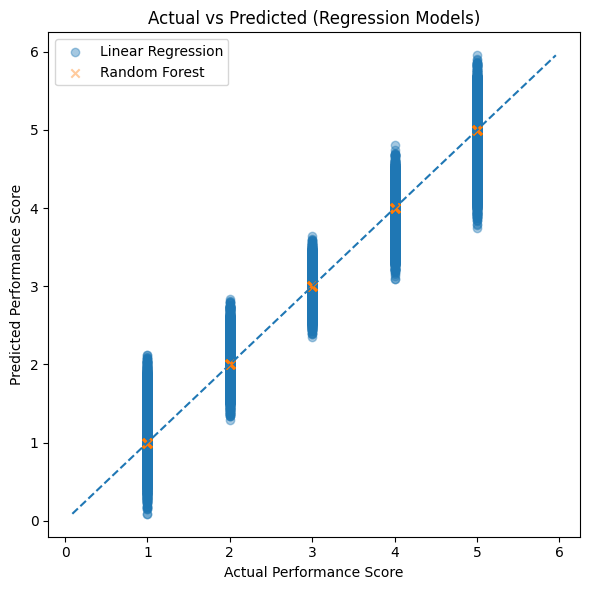

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(yr_test, pred_lin, alpha=0.4, label="Linear Regression")
plt.scatter(yr_test, pred_rf, alpha=0.4, marker="x", label="Random Forest")

min_val = min(yr_test.min(), pred_lin.min(), pred_rf.min())
max_val = max(yr_test.max(), pred_lin.max(), pred_rf.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Actual Performance Score")
plt.ylabel("Predicted Performance Score")
plt.title("Actual vs Predicted (Regression Models)")
plt.legend()
plt.tight_layout()
plt.show()


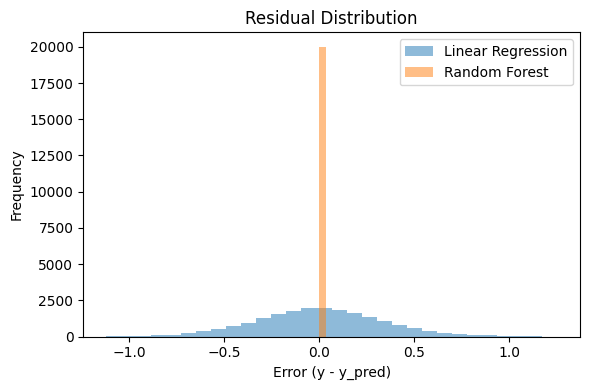

In [36]:
res_lin = yr_test - pred_lin
res_rf = yr_test - pred_rf

plt.figure(figsize=(6,4))
plt.hist(res_lin, bins=30, alpha=0.5, label="Linear Regression")
plt.hist(res_rf, bins=30, alpha=0.5, label="Random Forest")
plt.title("Residual Distribution")
plt.xlabel("Error (y - y_pred)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()


In [37]:
df.corr(numeric_only=True)["Performance_Score"].sort_values(ascending=False)


Performance_Score              1.000000
Monthly_Salary                 0.510035
Sick_Days                      0.002994
Training_Hours                 0.002358
Remote_Work_Frequency          0.001733
Employee_Satisfaction_Score    0.001696
Years_At_Company               0.001598
Age                            0.001598
Projects_Handled               0.000640
Overtime_Hours                -0.001312
Employee_ID                   -0.002077
Resigned                      -0.002714
Promotions                    -0.003501
Team_Size                     -0.005174
Work_Hours_Per_Week           -0.005627
Name: Performance_Score, dtype: float64

In [ ]:
model = rf_reg_model.named_steps["model"]

ohe = rf_reg_model.named_steps["prep"].named_transformers_["cat"]

encoded_cat_cols = ohe.get_feature_names_out()

import numpy as np
all_features = np.concatenate([encoded_cat_cols, num_cols])

import pandas as pd
imp = pd.Series(model.feature_importances_, index=all_features).sort_values(ascending=False)
imp.head(30)


ValueError: Length of values (3686) does not match length of index (3687)

In [56]:
print("Categorical columns:", cat_cols)
print("Numeric columns:", num_cols)
print("Total categorical expanded:", len(encoded_cat_cols))
print("Numeric columns count:", len(num_cols))
print("Sum:", len(encoded_cat_cols) + len(num_cols))
print("Feature importances length:", len(model.feature_importances_))


Categorical columns: ['Department', 'Gender', 'Job_Title', 'Education_Level']
Numeric columns: ['Employee_ID', 'Age', 'Years_At_Company', 'Performance_Score', 'Monthly_Salary', 'Work_Hours_Per_Week', 'Projects_Handled', 'Overtime_Hours', 'Sick_Days', 'Remote_Work_Frequency', 'Team_Size', 'Training_Hours', 'Promotions', 'Employee_Satisfaction_Score']
Total categorical expanded: 3673
Numeric columns count: 14
Sum: 3687
Feature importances length: 37
